In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [6]:
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
print(df.shape)

print(df.info())

print(df.describe())

(1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

In [8]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False).head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64

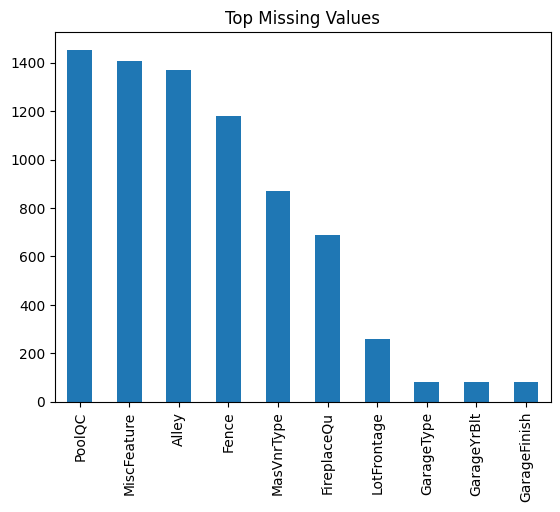

In [9]:
missing.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top Missing Values")

plt.show()

In [10]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

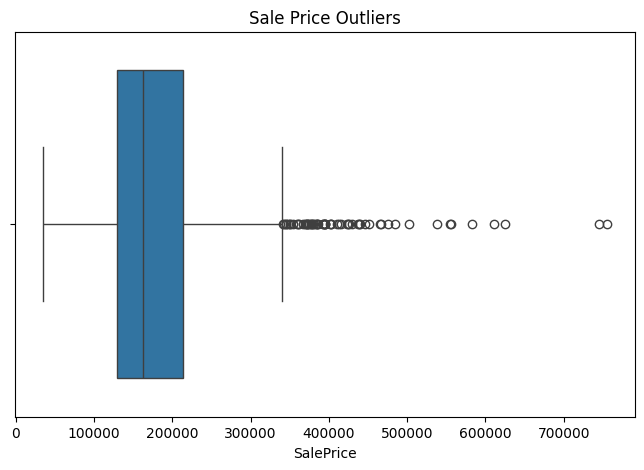

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['SalePrice'])

plt.title("Sale Price Outliers")

plt.show()

In [12]:
df = df[df['SalePrice'] < 500000]

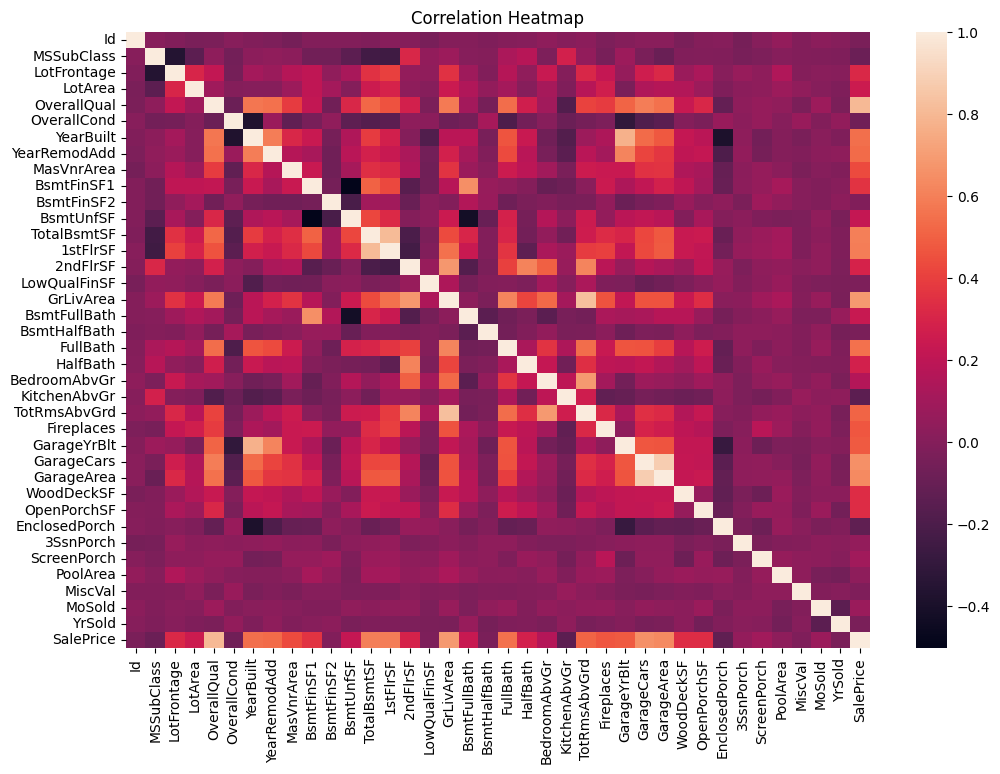

In [13]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
top_corr = corr['SalePrice'].sort_values(ascending=False)

print(top_corr.head(10))

SalePrice       1.000000
OverallQual     0.802424
GrLivArea       0.686872
GarageCars      0.654418
GarageArea      0.633607
TotalBsmtSF     0.596771
1stFlrSF        0.589676
FullBath        0.553014
YearBuilt       0.543898
YearRemodAdd    0.531708
Name: SalePrice, dtype: float64


In [15]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

In [16]:
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [17]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

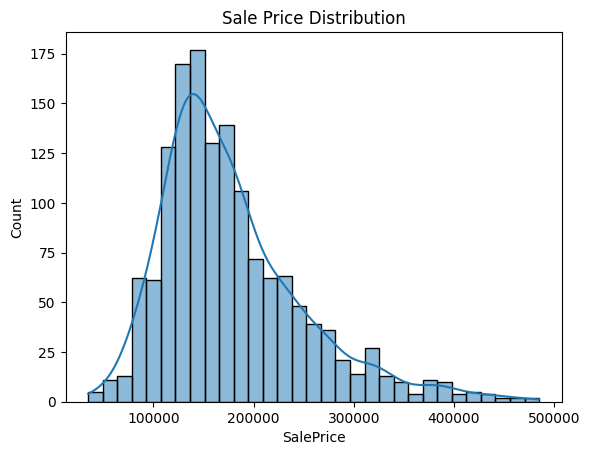

In [18]:
sns.histplot(df['SalePrice'], kde=True)

plt.title("Sale Price Distribution")

plt.show()

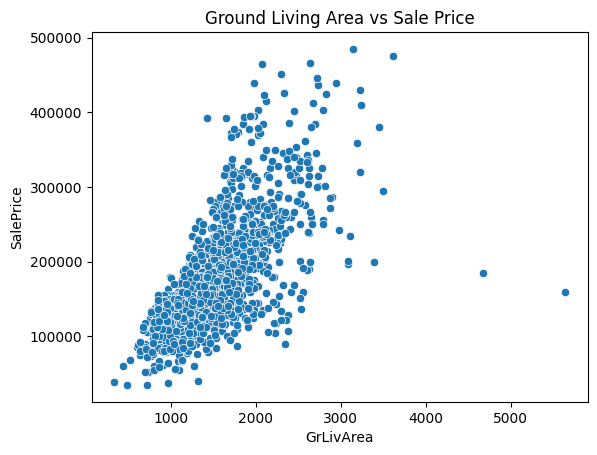

In [19]:
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])

plt.title("Ground Living Area vs Sale Price")

plt.show()

In [20]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge
0,1,60,3,65.0,8450,1,0,3,3,0,...,2,2,2,0,2,2008,8,4,208500,5
1,2,20,3,80.0,9600,1,0,3,3,0,...,2,2,2,0,5,2007,8,4,181500,31
2,3,60,3,68.0,11250,1,0,0,3,0,...,2,2,2,0,9,2008,8,4,223500,7
3,4,70,3,60.0,9550,1,0,0,3,0,...,2,2,2,0,2,2006,8,0,140000,91
4,5,60,3,84.0,14260,1,0,0,3,0,...,2,2,2,0,12,2008,8,4,250000,8
